# 📝 Actividad de Evaluación: Análisis Exploratorio de Portafolios (10%)

**Instrucciones:**
1. Resuelve cada uno de los puntos solicitados utilizando código de Python limpio y ordenado.
2. No olvides acompañar cada visualización con su respectiva **interpretación analítica** (recuerda la regla de oro: qué observas y qué significa).
3. Puedes realizar esta actividad de forma individual o en parejas (según las indicaciones del docente).

---

## 🏦 Paso 1: Selección y Descarga de Datos

1. Selecciona **3 activos financieros** diferentes a los utilizados en la clase (evita usar AAPL, MSFT, GOOGL, AMZN o NVDA).
2. Descarga los datos históricos utilizando `yfinance` para el periodo del **1 de enero de 2024** al **1 de enero de 2026**.
3. Muestra las primeras 5 filas del DataFrame resultante para validar la descarga.

In [20]:

# Importamos todas las librerias necesarias para trabajar e interpretar nuestros activos.
# Importamos las librerías
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual básica
sns.set_theme(style="whitegrid")

# Para que los gráficos aparezcan dentro del notebook
%matplotlib inline

In [37]:
#Aca tenemos las empresas que vamos a trabajar donde se encuentra su sector y su nombre

empresa=yf.Ticker("BAC")
empresa.info
empresa.info["sector"]
empresa.info["shortName"]
empresa.info["industry"]

print("Sector:", empresa.info["sector"])
print("Nombre corto:", empresa.info["shortName"])
print("Industria:", empresa.info["industry"])
print("-"*60)
#

empresa=yf.Ticker("ORCL")
empresa.info
empresa.info["sector"]
empresa.info["shortName"]
empresa.info["industry"]

print("Sector:", empresa.info["sector"])
print("Nombre corto:", empresa.info["shortName"])
print("Industria:", empresa.info["industry"])
print("-"*60)
#

empresa=yf.Ticker("COP")
empresa.info
empresa.info["sector"]
empresa.info["shortName"]
empresa.info["industry"]

print("Sector:", empresa.info["sector"])
print("Nombre corto:", empresa.info["shortName"])
print("Industria:", empresa.info["industry"])
#

Sector: Financial Services
Nombre corto: Bank of America Corporation
Industria: Banks - Diversified
------------------------------------------------------------
Sector: Technology
Nombre corto: Oracle Corporation
Industria: Software - Infrastructure
------------------------------------------------------------
Sector: Energy
Nombre corto: ConocoPhillips
Industria: Oil & Gas E&P


In [17]:
#Ahora seleccionamos los 3 activos financieros y descargamos los periodos.
tickers = ["BAC","ORCL","COP"]


precios = yf.download(
    tickers,
    start="2024-01-01",
    end="2026-01-01",
    auto_adjust=True
)

precios.head(1)

[*********************100%***********************]  3 of 3 completed


Price           Close                           High                          \
Ticker            BAC       COP       ORCL       BAC         COP        ORCL   
Date                                                                           
2024-01-02  31.800461  108.1772  100.81794  31.95993  109.290349  101.418626   

Price             Low                              Open              \
Ticker            BAC         COP       ORCL        BAC         COP   
Date                                                                  
2024-01-02  31.209478  107.496438  99.248417  31.322045  107.790822   

Price                     Volume                    
Ticker            ORCL       BAC      COP     ORCL  
Date                                                
2024-01-02  101.263607  36668600  4688400  9597500

## 📈 Paso 2: Análisis de Precios de Cierre y Normalización

1. Filtra y extrae únicamente los precios de cierre (`Close`).
2. Grafica en una sola figura la evolución temporal de los precios originales de tus 3 activos.
3. Realiza la normalización (base 100 en el primer registro) y grafica nuevamente las series en otra figura.

### 💬 Pregunta de interpretación #1:
Al comparar ambos gráficos (precios reales vs. precios normalizados), ¿por qué es metodológicamente más correcto utilizar el gráfico normalizado para comparar el rendimiento histórico de los activos? Explica la diferencia en el comportamiento visual observado.

In [8]:
#Ahora con los precios de cierre donde en la tabla siguiente solo ponemos los 5 primeros por cuestion de orden
cierre = precios["Close"]

cierre.head()

Ticker,BAC,COP,ORCL
Date,,,
2024-01-02,31.800461,108.177200,100.817940
2024-01-03,31.453379,110.329880,99.267807
2024-01-04,31.706657,107.156036,99.393738
2024-01-05,32.297634,107.202034,99.529381
2024-01-08,32.044357,105.334541,101.399246


In [9]:
#Ahora cogemos los precios de cierre y los normalizamos con base 100

cierre_normalizado = cierre / cierre.iloc[0] * 100

cierre_normalizado.head()

Ticker,BAC,COP,ORCL
Date,,,
2024-01-02,100.000000,100.000000,100.000000
2024-01-03,98.908563,101.989957,98.462444
2024-01-04,99.705025,99.056027,98.587353
2024-01-05,101.563415,99.098547,98.721895
2024-01-08,100.766959,97.372220,100.576590


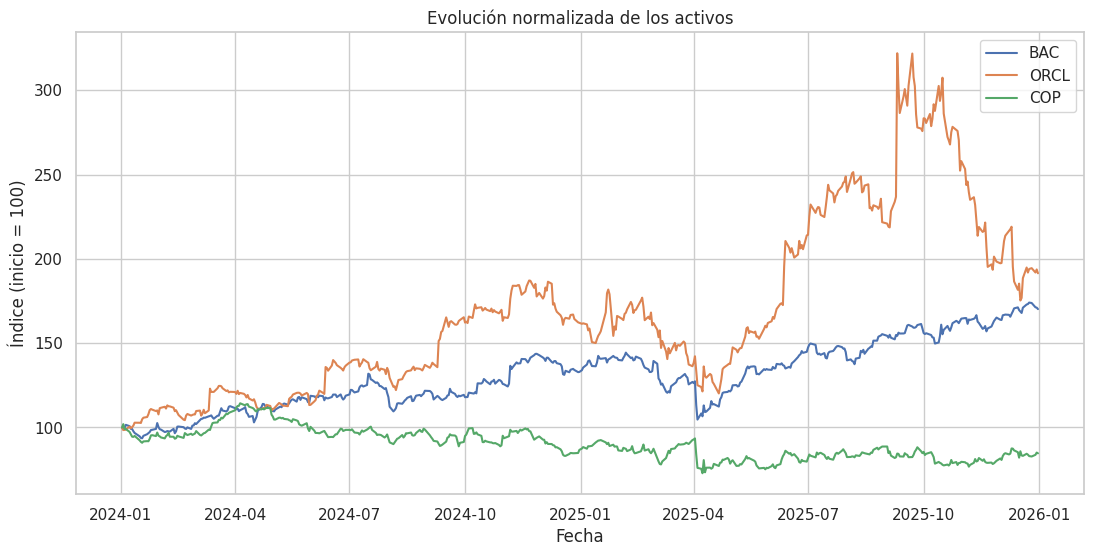

In [11]:
fig, ax = plt.subplots(figsize=(13, 6))

for activo in tickers:
    ax.plot(
        cierre_normalizado.index,
        cierre_normalizado[activo],
        label=activo
    )

ax.set_title("Evolución normalizada de los activos")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice (inicio = 100)")
ax.legend()

plt.show()

**Como podemos observar tenemos la tabla, pero para poder analizar tenemos el grafico el cual nos indica que 2 empresas han tenido un crecimiento desde el inicio del periodo en cuestion la cuales son Oracle corp (ORCL) que es una empresa de software y tecnologia y Bank of america (BAC); por otro lado a diferencia de ConocoPhillips (COP) que es una empresa de energia ha tenido un decrecimiento, en la mayoria del periodo.**

## 🔄 Paso 3: Cálculo y Distribución de Rendimientos

1. Calcula los rendimientos diarios de los activos y elimina los valores nulos (`NaN`).
2. Genera un **histograma* para el activo que consideres que haya sido el más volátil.
3. Diseña un **Boxplot** comparativo que muestre los rendimientos diarios de tus 3 activos simultáneamente.

### 💬 Pregunta de interpretación #2:
Observando el Boxplot y el Histograma:
- ¿Qué activo presenta la mayor dispersión (caja más amplia o bigotes más largos) y qué te dice esto sobre su riesgo?
- ¿Identificas valores atípicos (outliers)? ¿Qué representan estos puntos en el contexto de la historia económica reciente de estas empresas?

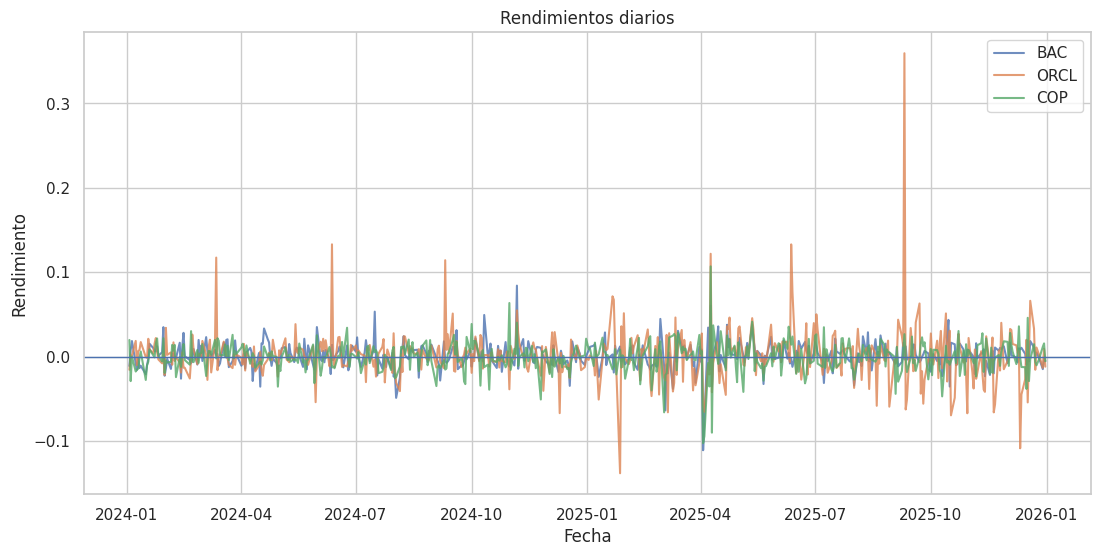

In [55]:
# Aca calculamos los rendimientos diarios con su grafico, el cual nos indica si su precio vario mucho o no durante los dias de nue

rendimientos = cierre.pct_change()

rendimientos.head()

rendimientos = rendimientos.dropna()

rendimientos.head()

fig, ax = plt.subplots(figsize=(13, 6))

for activo in tickers:
    ax.plot(
        rendimientos.index,
        rendimientos[activo],
        label=activo,
        alpha=0.8
    )

ax.axhline(0, linewidth=1)
ax.set_title("Rendimientos diarios")
ax.set_xlabel("Fecha")
ax.set_ylabel("Rendimiento")
ax.legend()

plt.show()


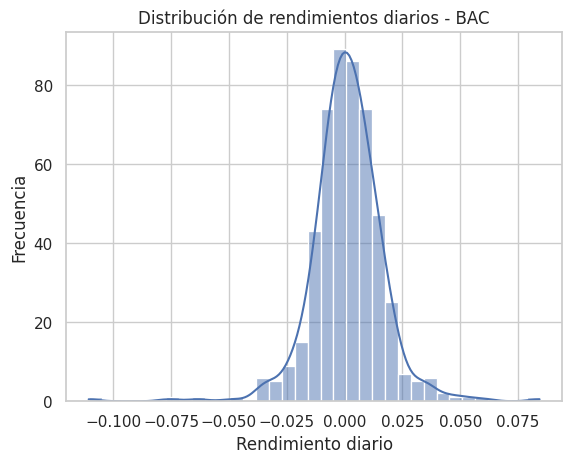

------------------------------------------------------------


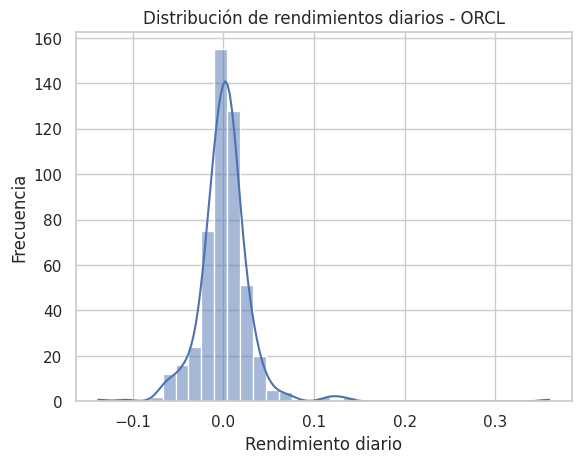

------------------------------------------------------------


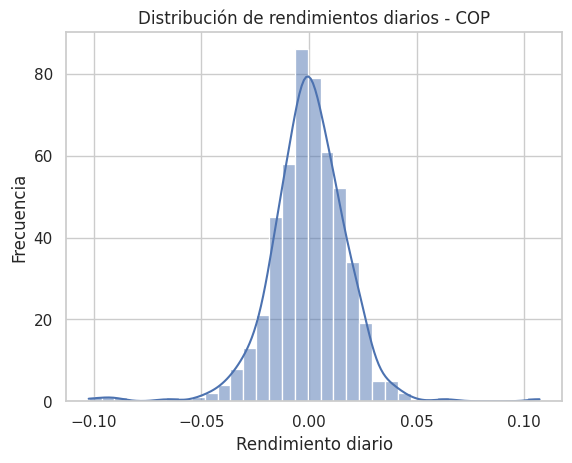

In [45]:
#Aca construimos el histograma para los activos

sns.histplot(
    data=rendimientos,
    x="BAC",
    bins=35,
    kde=True
)

plt.title("Distribución de rendimientos diarios - BAC")
plt.xlabel("Rendimiento diario")
plt.ylabel("Frecuencia")

plt.show()
print("-"*60)
sns.histplot(
    data=rendimientos,
    x="ORCL",
    bins=35,
    kde=True
)

plt.title("Distribución de rendimientos diarios - ORCL")
plt.xlabel("Rendimiento diario")
plt.ylabel("Frecuencia")

plt.show()
print("-"*60)

sns.histplot(
    data=rendimientos,
    x="COP",
    bins=35,
    kde=True
)

plt.title("Distribución de rendimientos diarios - COP")
plt.xlabel("Rendimiento diario")
plt.ylabel("Frecuencia")

plt.show()

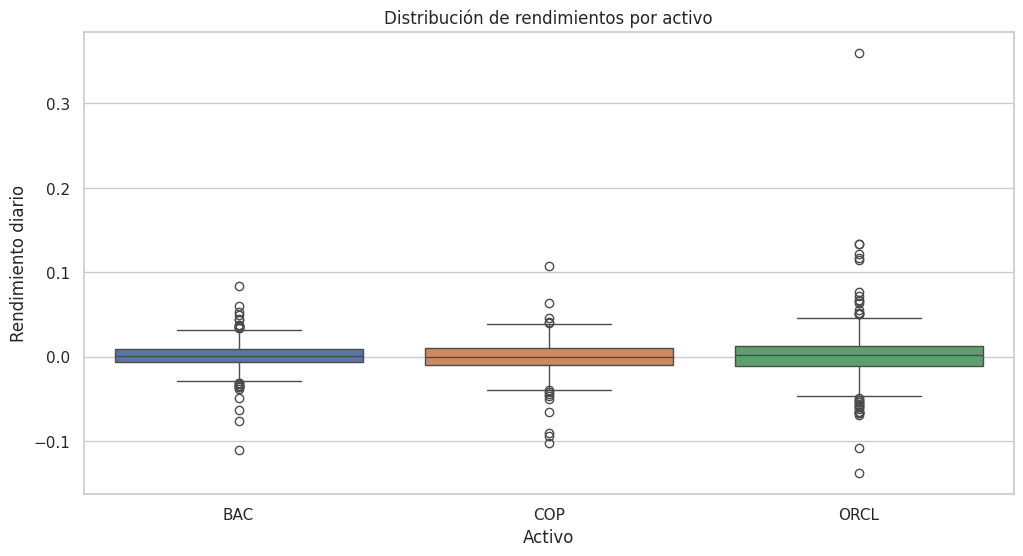

In [46]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=rendimientos)

plt.title("Distribución de rendimientos por activo")
plt.xlabel("Activo")
plt.ylabel("Rendimiento diario")

plt.show()

**Como podemos observar los rendimientos el activo que mas varia su valor es ORCL el cual tiene una mayor dispersion en sus datos por ende es entendible que su rendimiento a sido el mas variado a diferencia de BAC y COP que son los que a comparacion son los que menos movimientos en su rendimiento han tenido**

## 📊 Paso 4: Asociación y Correlación

1. Calcula la matriz de correlación de Pearson para los rendimientos de tus 3 activos.
2. Grafica un **mapa de calor (Heatmap)**.

### 💬 Pregunta de interpretación #3:
- ¿Existe alguna correlación fuerte (cercana a 1 o -1) entre alguno de tus activos?
- Si tuvieras que armar un portafolio de inversión buscando la **diversificación** (minimizar el riesgo conjunto), ¿qué par de activos elegirías de acuerdo a tus resultados y por qué?

In [56]:
#Aca calculamos la matriz de correlacion de los activos
correlacion = rendimientos.corr()

correlacion

Ticker,BAC,COP,ORCL
Ticker,,,
BAC,1.000000,0.408410,0.204207
COP,0.408410,1.000000,0.190135
ORCL,0.204207,0.190135,1.000000


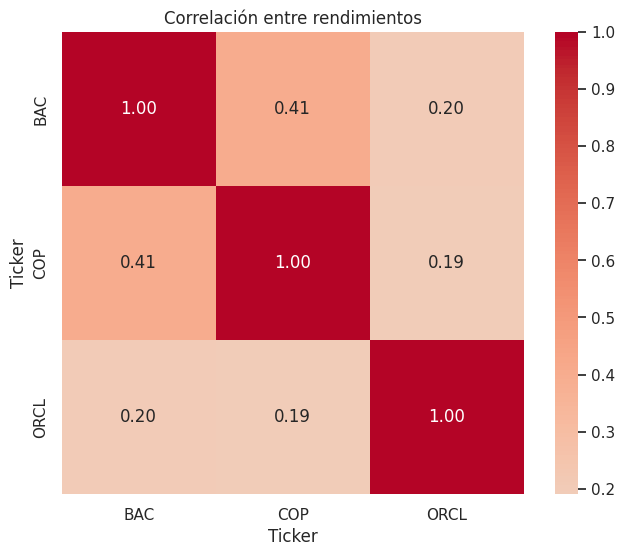

In [57]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlación entre rendimientos")

plt.show()

**Como podemo observar todos los activos estan correlacionados entre si, ya que todos tienen valores positivos, pero el que mas correlacion tine son COP y BAC, esto nos quiere decir que si el precio sube ambas suben y viceversa y el que menos correlacion tinen son COP y ORCL.**

## 🧮 Paso 5: Estadísticas Descriptivas y Conclusión

1. Genera un DataFrame de resumen estadístico que incluya para cada activo: Media, Mediana, Desviación Estándar, Mínimo y Máximo de los rendimientos diarios.
2. Escribe una breve conclusión final dirigida a un inversionista ficticio, interpretando los estadísticos clave obtenidos.

In [59]:
#Por ultimo sacamos la estadistica descriptiva de nuestros activos
resumen = pd.DataFrame({
    "Media": rendimientos.mean(),
    "Mediana": rendimientos.median(),
    "Desviación estándar": rendimientos.std(),
    "Mínimo": rendimientos.min(),
    "Máximo": rendimientos.max()
})

resumen


,Media,Mediana,Desviación estándar,Mínimo,Máximo
Ticker,,,,,
BAC,0.001185,0.001217,0.015617,-0.110633,0.084288
COP,-0.000168,-0.000267,0.018072,-0.102262,0.107065
ORCL,0.001750,0.001991,0.030972,-0.137909,0.359488


Como podemos observa viendo los datos estadisticos, que el que mayor rendimiento ha tenido en este periodo es ORCL como tambien pudimos observar en  la grafica anterior pero como podemos observar tambien es un activo muy volatil, entonces hay que analizar el perfil de riesgo del inversionista para saber si es arriesgado la mejor opcion es ORCL y si prefiere protegerlo la mejor es BAC ya que sus rendimientos son positivos al igual que su crecimiento pero de una forma mas estable.

"Cabe destacar que lo que nos indican los valores no significa que siga asi" **texto en negrita**